In [ ]:
import pandas as pd

df = pd.read_sas(r"C:\Users\Owner\Downloads\LLCP2024XPT\LLCP2024.XPT", format="xport")
df.to_csv("BRFSS_2024.csv", index=False)

In [5]:
import pandas as pd

df = pd.read_csv(r"C:\Users\Owner\Downloads\BRFSS_2024.csv", low_memory=False)

In [13]:
df.columns

Index(['_STATE', 'FMONTH', 'IDATE', 'IMONTH', 'IDAY', 'IYEAR', 'DISPCODE',
       'SEQNO', '_PSU', 'CTELENM1',
       ...
       '_LCSCTSN', '_LCSPSTF', 'DRNKANY6', 'DROCDY4_', '_RFBING6', '_DRNKWK3',
       '_RFDRHV9', '_FLSHOT7', '_PNEUMO3', '_AIDTST4'],
      dtype='object', length=301)

In [20]:
#The dataset has 300+ columns. keeping only the mental‑health and demographic variables relevant to your project.
cols = [
    "MENTHLTH", "GENHLTH",
    "SEXVAR", "_AGEG5YR", "INCOME3", "EDUCA",
    "EMPLOY1", "MARITAL", "_STATE"
]

df = df[cols]


In [21]:
df.head(5)

,MENTHLTH,GENHLTH,SEXVAR,_AGEG5YR,INCOME3,EDUCA,EMPLOY1,MARITAL,_STATE
0,88.0,3.0,2.0,12.0,99.0,4.0,7.0,3.0,1.0
1,88.0,1.0,1.0,13.0,11.0,6.0,7.0,1.0,1.0
2,88.0,2.0,1.0,8.0,99.0,5.0,1.0,6.0,1.0
3,88.0,1.0,1.0,13.0,6.0,6.0,7.0,1.0,1.0
4,88.0,3.0,1.0,6.0,3.0,5.0,8.0,5.0,1.0


In [22]:
#BRFSS uses special numbers like 7, 9, 77, 99 to mean “Refused,” “Don’t know,” or “Missing.”
#convert them to NaN so they don’t distort your analysis.
import numpy as np

missing_codes = [7, 9, 77, 99, 777, 999]
df = df.replace(missing_codes, np.nan)

In [23]:
#Demographic variables are stored as numbers (e.g., 1, 2, 3).
#convert them into readable labels like “Male,” “College graduate,” etc.
gender_map = {1: "Male", 2: "Female"}
df["gender"] = df["SEXVAR"].map(gender_map)


In [25]:
age_map = {
    1: "18–24", 2: "25–29", 3: "30–34", 4: "35–39", 5: "40–44",
    6: "45–49", 7: "50–54", 8: "55–59", 9: "60–64", 10: "65–69",
    11: "70–74", 12: "75–79", 13: "80+"
}
df["age_group"] = df["_AGEG5YR"].map(age_map)

In [26]:
income_map = {
    1: "<$10k", 2: "$10k–$15k", 3: "$15k–$20k", 4: "$20k–$25k",
    5: "$25k–$35k", 6: "$35k–$50k", 7: "$50k–$75k", 8: "$75k+"
}
df["income"] = df["INCOME3"].map(income_map)

In [27]:
edu_map = {
    1: "Never attended school",
    2: "Elementary",
    3: "Some high school",
    4: "High school graduate",
    5: "Some college",
    6: "College graduate"
}
df["education"] = df["EDUCA"].map(edu_map)

In [28]:
emp_map = {
    1: "Employed for wages",
    2: "Self-employed",
    3: "Out of work <1 year",
    4: "Out of work >1 year",
    5: "Homemaker",
    6: "Student",
    7: "Retired",
    8: "Unable to work"
}
df["employment"] = df["EMPLOY1"].map(emp_map)

In [29]:
#MENTHLTH tells you how many days in the past 30 days a person felt mentally unwell.
#convert it into categories to make analysis easier.
def categorize_mental_health(days):
    if pd.isna(days):
        return np.nan
    if days == 0:
        return "No poor MH days"
    elif days <= 7:
        return "1–7 days"
    elif days <= 14:
        return "8–14 days"
    else:
        return "15+ days"

df["mh_category"] = df["MENTHLTH"].apply(categorize_mental_health)


In [30]:
#remove rows where essential variables (like age, gender, mental‑health days) are missing.
df_clean = df.dropna(subset=["MENTHLTH", "age_group", "gender"])

In [31]:
#A clean, analysis‑ready dataset with:mental‑health categories,demographic labels, missing values handled and 
#consistent structure ready for visualizations and insights
df_clean.to_csv("BRFSS_2024_cleaned.csv", index=False)

In [32]:
#Basic Data Understanding
df_clean.info()
df_clean.describe()
df_clean.isna().mean().sort_values(ascending=False).head(10)


<class 'pandas.core.frame.DataFrame'>
Index: 360297 entries, 0 to 457668
Data columns (total 15 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   MENTHLTH     360297 non-null  float64
 1   GENHLTH      359459 non-null  float64
 2   SEXVAR       360297 non-null  float64
 3   _AGEG5YR     360297 non-null  float64
 4   INCOME3      200268 non-null  float64
 5   EDUCA        359021 non-null  float64
 6   EMPLOY1      225697 non-null  float64
 7   MARITAL      357985 non-null  float64
 8   _STATE       354761 non-null  float64
 9   gender       360297 non-null  object 
 10  age_group    360297 non-null  object 
 11  income       158012 non-null  object 
 12  education    359021 non-null  object 
 13  employment   225697 non-null  object 
 14  mh_category  360297 non-null  object 
dtypes: float64(9), object(6)
memory usage: 44.0+ MB


income        0.561440
INCOME3       0.444159
EMPLOY1       0.373581
employment    0.373581
_STATE        0.015365
MARITAL       0.006417
EDUCA         0.003542
education     0.003542
GENHLTH       0.002326
MENTHLTH      0.000000
dtype: float64

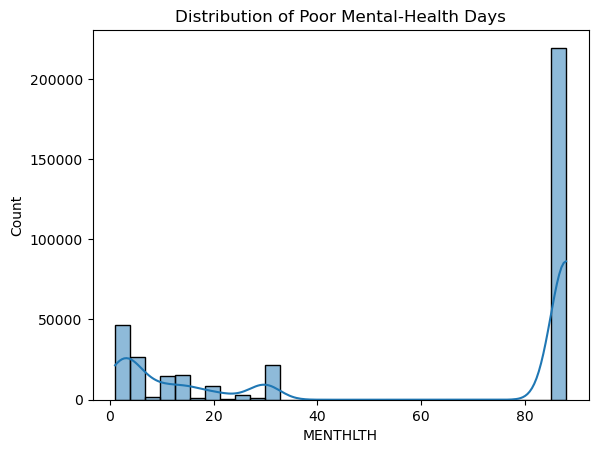

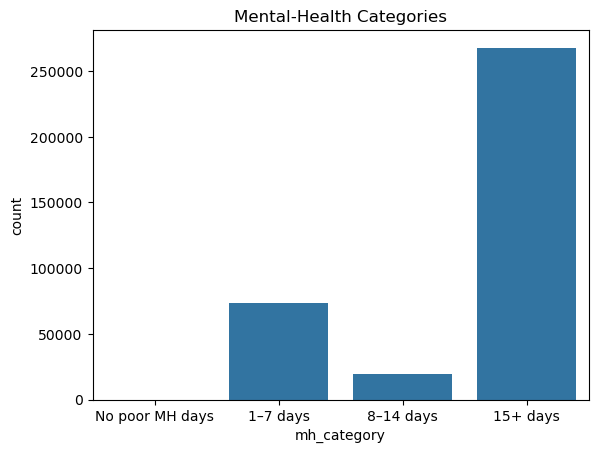

In [34]:
#Distribution of Mental‑Health Days
#How many poor mental‑health days do people report?
#Histogram and barchart foor categories 
import seaborn as sns
import matplotlib.pyplot as plt

sns.histplot(df_clean["MENTHLTH"], bins=30, kde=True)
plt.title("Distribution of Poor Mental-Health Days")
plt.show()

sns.countplot(data=df_clean, x="mh_category", order=["No poor MH days","1–7 days","8–14 days","15+ days"])
plt.title("Mental-Health Categories")
plt.show()


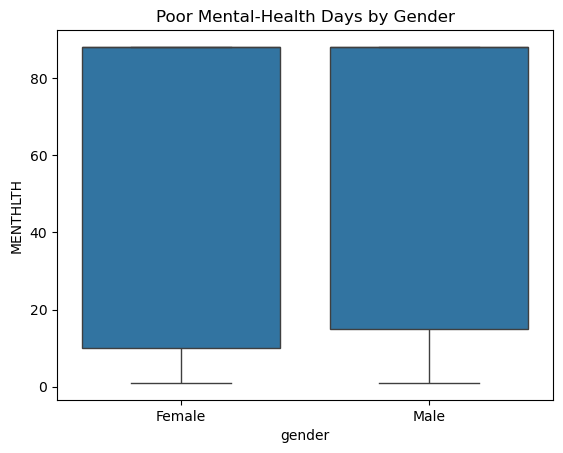

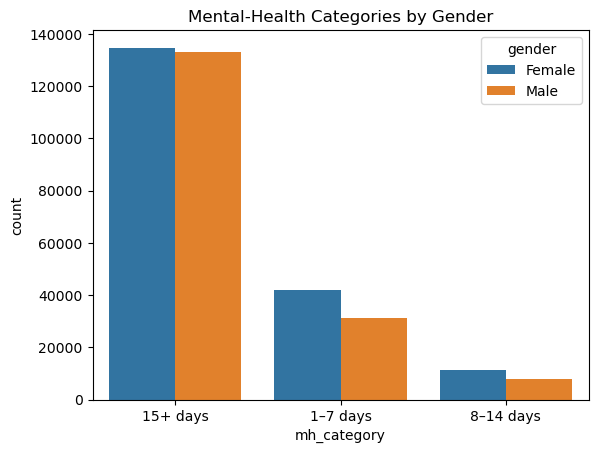

In [35]:
#Mental Health by Gender
#Do men and women report different mental‑health patterns?
#Barchart and Box plot
sns.boxplot(data=df_clean, x="gender", y="MENTHLTH")
plt.title("Poor Mental-Health Days by Gender")
plt.show()

sns.countplot(data=df_clean, x="mh_category", hue="gender")
plt.title("Mental-Health Categories by Gender")
plt.show()

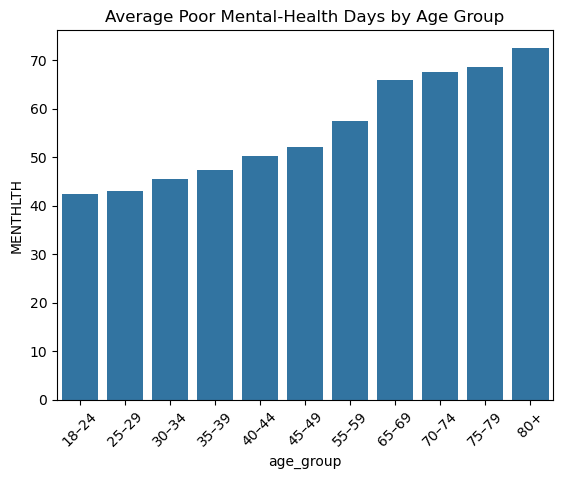

In [36]:
#Mental Health by Age Group
#Which age groups report the most poor mental‑health days?
#Bar chart and Line plot (age vs. mean mental‑health days)
age_mh = df_clean.groupby("age_group")["MENTHLTH"].mean().reset_index()

sns.barplot(data=age_mh, x="age_group", y="MENTHLTH")
plt.xticks(rotation=45)
plt.title("Average Poor Mental-Health Days by Age Group")
plt.show()



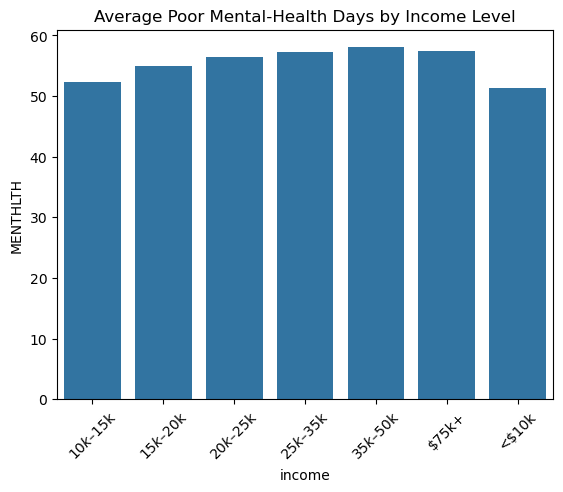

In [37]:
#Mental Health by Income
#Does income level relate to mental‑health burden?
#Barchart and Boxpllot

income_mh = df_clean.groupby("income")["MENTHLTH"].mean().reset_index()

sns.barplot(data=income_mh, x="income", y="MENTHLTH")
plt.xticks(rotation=45)
plt.title("Average Poor Mental-Health Days by Income Level")
plt.show()

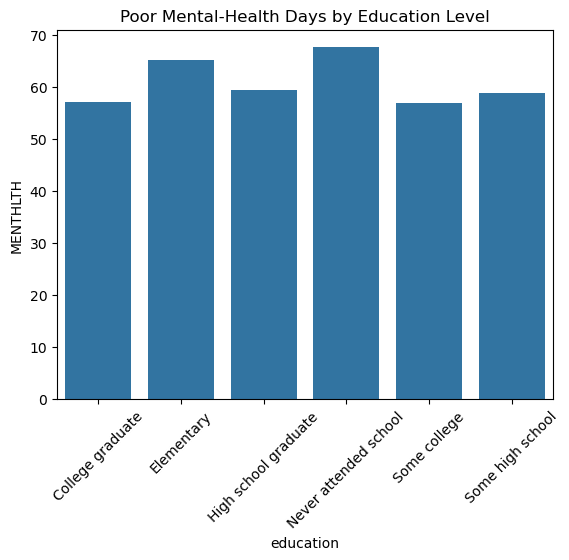

In [38]:
#Mental Health by Education
#Does education level correlate with mental‑health outcomes?
#Bar chart annd count plot

edu_mh = df_clean.groupby("education")["MENTHLTH"].mean().reset_index()

sns.barplot(data=edu_mh, x="education", y="MENTHLTH")
plt.xticks(rotation=45)
plt.title("Poor Mental-Health Days by Education Level")
plt.show()

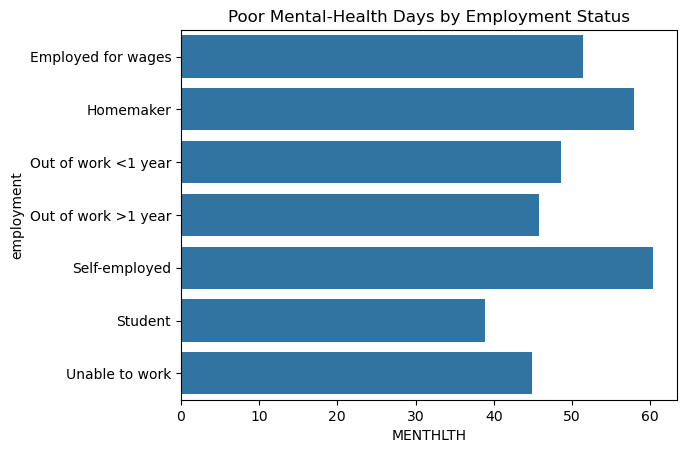

In [39]:
#Mental Health by Employment Statu
#Which employment groups report the highest mental‑health burden?
#Bar cgart and Horizontal Barchart

emp_mh = df_clean.groupby("employment")["MENTHLTH"].mean().reset_index()

sns.barplot(data=emp_mh, y="employment", x="MENTHLTH")
plt.title("Poor Mental-Health Days by Employment Status")
plt.show()

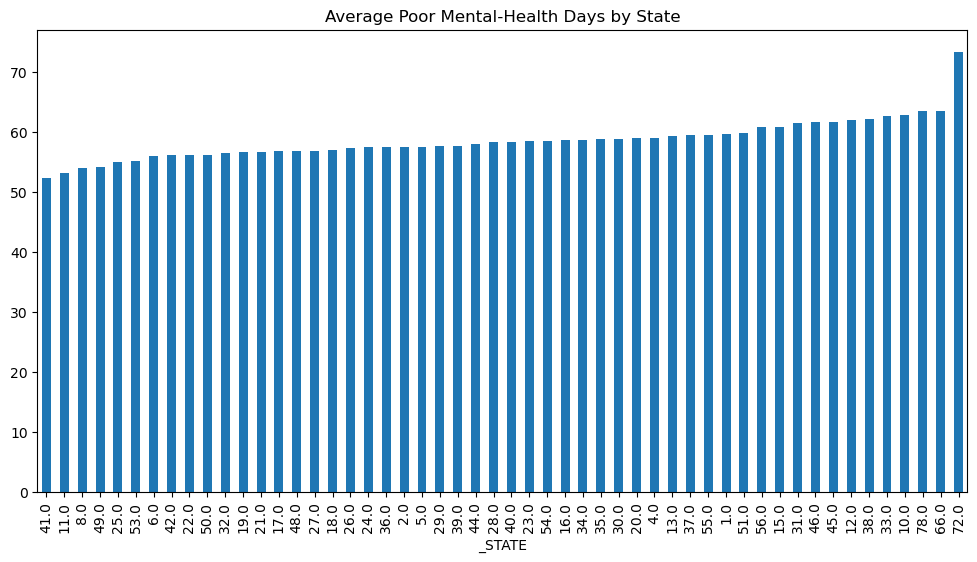

In [40]:
#Do mental‑health patterns vary across states?
#bar chart
state_mh = df_clean.groupby("_STATE")["MENTHLTH"].mean().sort_values()

state_mh.plot(kind="bar", figsize=(12,6))
plt.title("Average Poor Mental-Health Days by State")
plt.show()


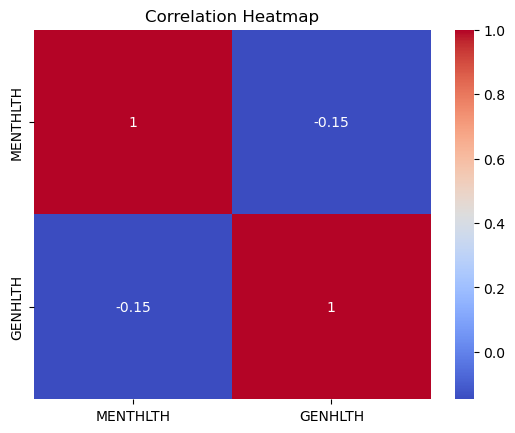

In [41]:
#How do demographic variables relate to mental‑health days?
numeric_df = df_clean[["MENTHLTH", "GENHLTH"]].copy()

sns.heatmap(numeric_df.corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

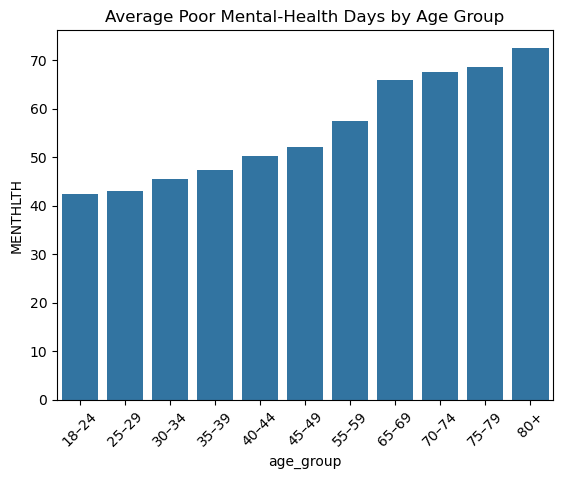

In [43]:
# Image 1
#Average Poor Mental‑Health Days by Age Group

sns.barplot(data=age_mh, x="age_group", y="MENTHLTH")
plt.xticks(rotation=45)
plt.title("Average Poor Mental-Health Days by Age Group")
plt.savefig('image1', dpi=300, bbox_inches='tight')
plt.show()

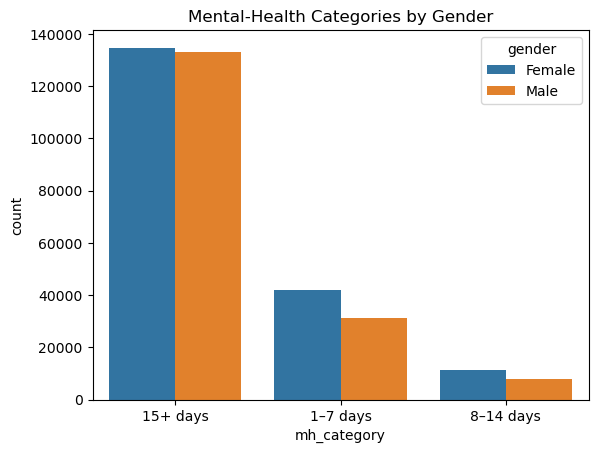

In [44]:
#Image 2
#Mental‑Health Categories by Gender
sns.countplot(data=df_clean, x="mh_category", hue="gender")
plt.title("Mental-Health Categories by Gender")
plt.savefig('image2', dpi=300, bbox_inches='tight')
plt.show()


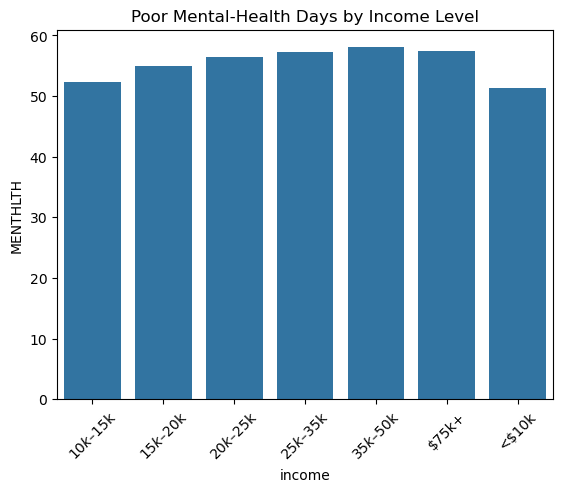

In [45]:
#Image 3
#Mental‑Health Days by Income Level

sns.barplot(data=income_mh, x="income", y="MENTHLTH")
plt.xticks(rotation=45)
plt.title("Poor Mental-Health Days by Income Level")
plt.savefig('image3', dpi=300, bbox_inches='tight')
plt.show()

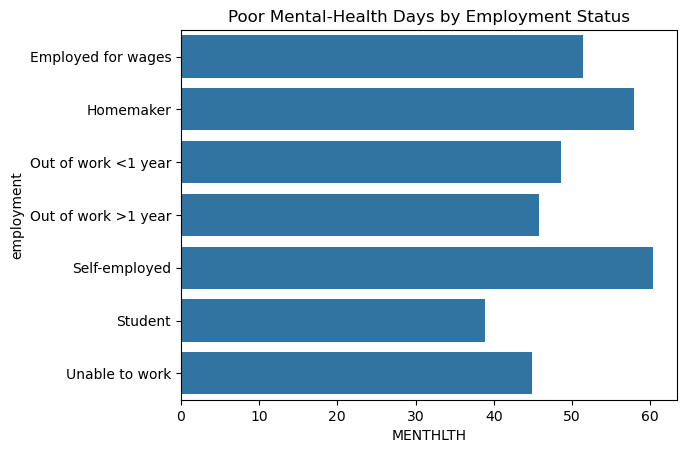

In [46]:
#Image 4
#Mental‑Health Days by Employment Status
sns.barplot(data=emp_mh, y="employment", x="MENTHLTH")
plt.title("Poor Mental-Health Days by Employment Status")
plt.savefig('image4', dpi=300, bbox_inches='tight')
plt.show()

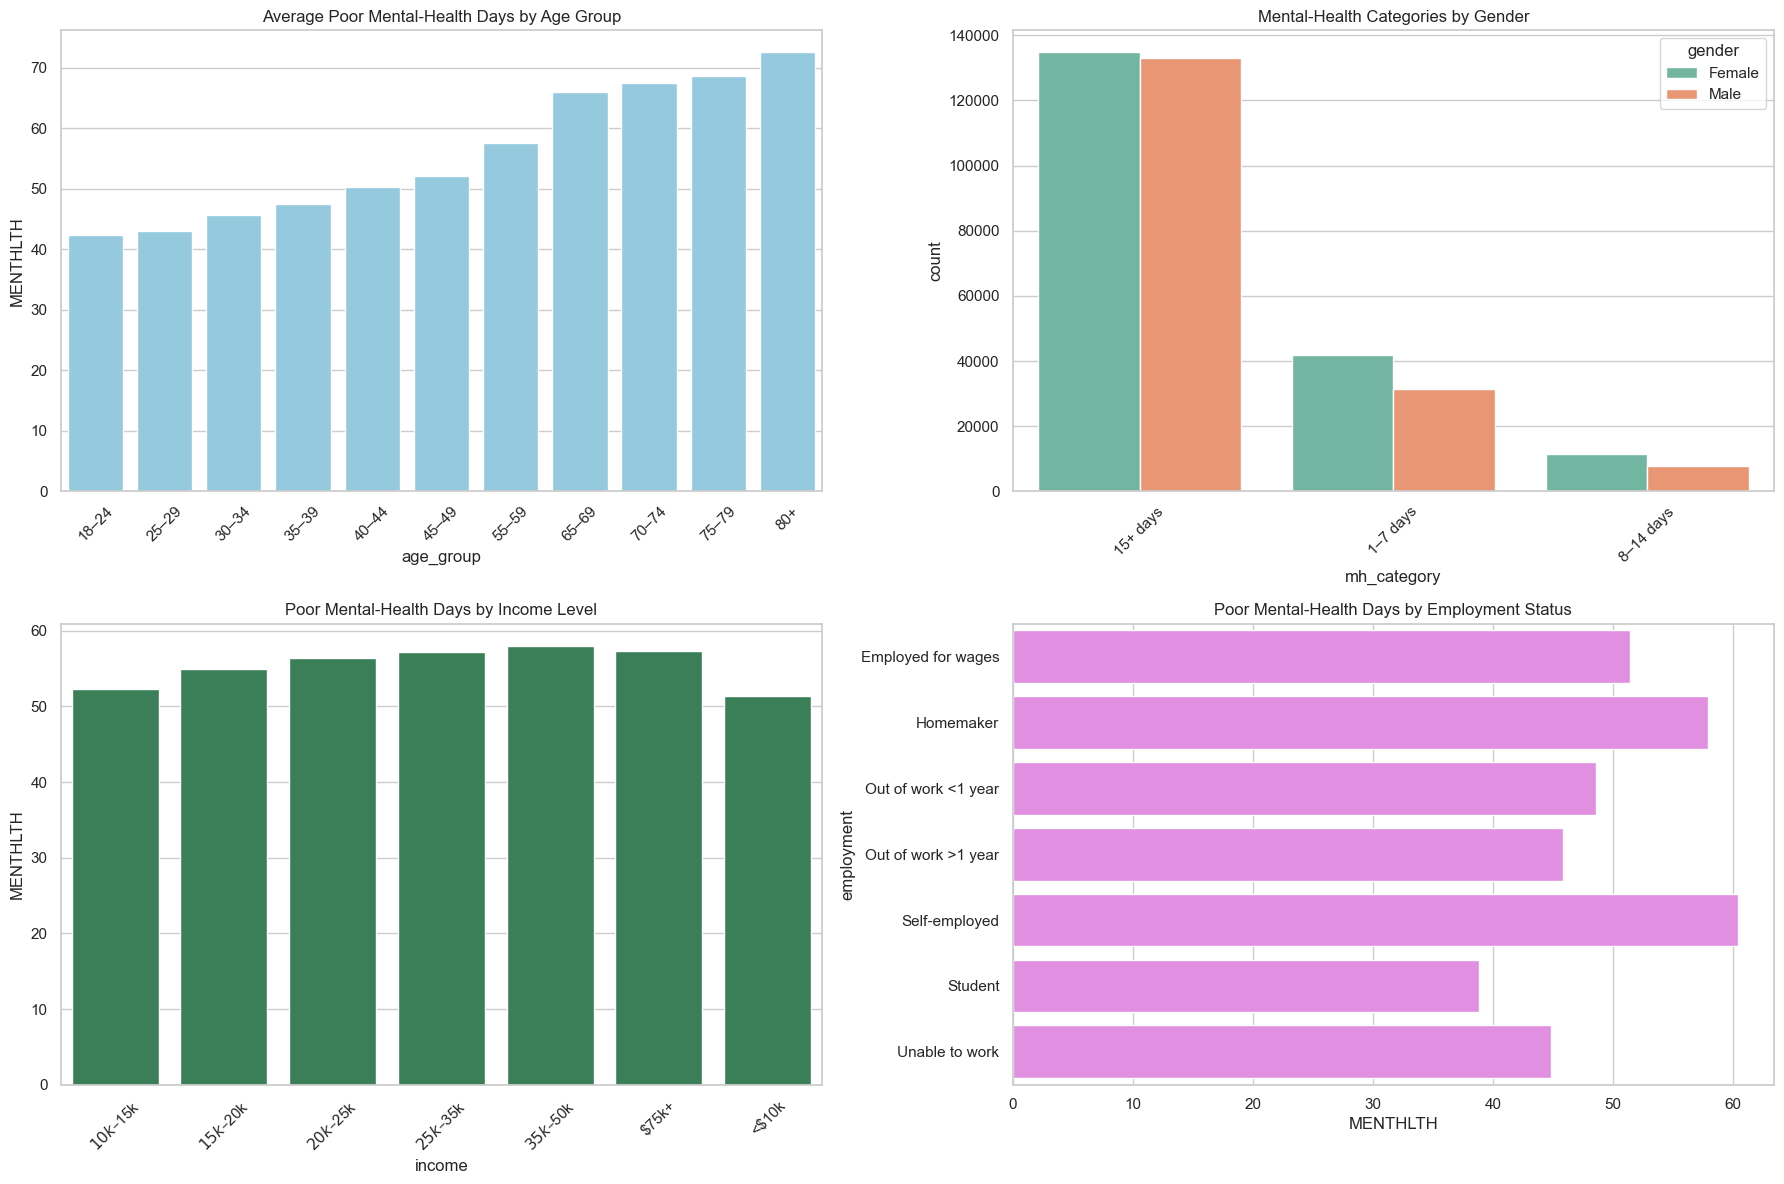

In [51]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set a clean style
sns.set(style="whitegrid")

# Create a 2x2 grid
fig, axes = plt.subplots(2, 2, figsize=(18, 12))

# -----------------------------------------
# 1️⃣ Mental Health by Age Group
# -----------------------------------------
sns.barplot(
    data=age_mh,
    x="age_group",
    y="MENTHLTH",
    ax=axes[0, 0],
    color="skyblue"
)
axes[0, 0].set_title("Average Poor Mental-Health Days by Age Group")
axes[0, 0].tick_params(axis='x', rotation=45)

# -----------------------------------------
# 2️⃣ Mental Health Categories by Gender
# -----------------------------------------
sns.countplot(
    data=df_clean,
    x="mh_category",
    hue="gender",
    ax=axes[0, 1],
    palette="Set2"
)
axes[0, 1].set_title("Mental-Health Categories by Gender")
axes[0, 1].tick_params(axis='x', rotation=45)

# -----------------------------------------
# 3️⃣ Mental Health by Income Level
# -----------------------------------------
sns.barplot(
    data=income_mh,
    x="income",
    y="MENTHLTH",
    ax=axes[1, 0],
    color="seagreen"
)
axes[1, 0].set_title("Poor Mental-Health Days by Income Level")
axes[1, 0].tick_params(axis='x', rotation=45)

# -----------------------------------------
# 4️⃣ Mental Health by Employment Status
# -----------------------------------------
sns.barplot(
    data=emp_mh,
    y="employment",
    x="MENTHLTH",
    ax=axes[1, 1],
    color="violet"
)
axes[1, 1].set_title("Poor Mental-Health Days by Employment Status")

# Adjust layout
plt.tight_layout()
plt.savefig('image5', dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
Over the past few days, as part of my Python learning journey, I’ve been exploring the 2024 BRFSS (Behavioral Risk Factor Surveillance System) dataset — one of the largest public‑health surveys in the world — to understand how mental‑health patterns vary across demographic groups.
What started as a simple data‑cleaning exercise quickly turned into something much more meaningful. The data tells a powerful story:
🔹 Younger adults report the highest number of poor mental‑health days
🔹 Women consistently report more mental‑health challenges than men
🔹 Lower‑income groups show a noticeably higher mental‑health burden
🔹 Employment status matters — especially for those unable to work
What I love about projects like this is how data transforms into empathy.
Behind every row is a real person navigating stress, uncertainty, and resilience.
This project reminded me why I love working with data — it’s not just about cleaning columns or generating charts. It’s about uncovering patterns that help us understand people better and support healthier communities.